In [1]:
import sys
!{sys.executable} -m pip install scikit-learn imbalanced-learn xgboost scikit-image pillow matplotlib seaborn scipy

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from skimage.feature import graycomatrix, graycoprops
from skimage.color import rgb2gray, rgb2hsv
from skimage import img_as_ubyte

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score)
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

import xgboost as xgb

In [4]:
import os

# Images are inside ham_images folder
IMG_DIRS = [
    "ham_images/HAM10000_images_part_1",
    "ham_images/HAM10000_images_part_2"
]

for folder in IMG_DIRS:
    count = len([f for f in os.listdir(folder) if f.endswith(".jpg")])
    print(f"✅ {folder}: {count} images")

✅ ham_images/HAM10000_images_part_1: 5000 images
✅ ham_images/HAM10000_images_part_2: 5015 images


In [13]:
DATA_DIR  = "."
META_CSV  = "ham_images/HAM10000_metadata.csv"

IMG_DIRS = [
    "ham_images/HAM10000_images_part_1",
    "ham_images/HAM10000_images_part_2"
]

IMG_SIZE    = (128, 128)
RANDOM_SEED = 42

In [14]:
import os
print(os.listdir())

['.git', '.gitignore', 'data_preprocess_eda (1).ipynb', 'data_preprocess_eda.ipynb', 'eda_age_boxplots.png', 'eda_class_age.png', 'eda_feature_distributions.png', 'eda_sample_grid.png', 'eda_sex_class_heatmap.png', 'Feature_Engineering_And_Model_Training.ipynb', 'glcm_features.csv', 'ham_images', 'ham_images.zip', 'hsv_features.csv', 'load.ipynb', 'preprocessing_validation.png', 'processed_ids.npy', 'processed_images.npy', 'README.md', 'scaler.pkl', 'Screenshot 2026-04-05 085204.png', 'shape_features.csv', 'svm_model.pkl', 'xgb_model.pkl']


In [15]:
import cv2

def load_image(image_id):
    img_name = image_id + ".jpg"
    
    for d in IMG_DIRS:
        path = os.path.join(d, img_name)
        if os.path.exists(path):
            return cv2.imread(path)
    
    return None

In [16]:
import pandas as pd

df = pd.read_csv(META_CSV)

img = load_image(df.iloc[0]['image_id'])

print(img.shape)

(450, 600, 3)


In [17]:
# 1.  LABEL MAP
# ─────────────────────────────────────────────
LABEL_MAP = {
    "mel":  "Melanoma",
    "bcc":  "Basal Cell Carcinoma",
    "akiec":"Actinic Keratoses",
    "bkl":  "Benign Keratosis",
    "df":   "Dermatofibroma",
    "nv":   "Melanocytic Nevi",
    "vasc": "Vascular Lesions",
}

In [18]:
# ── Stage 2: Dataset Overview ─────────────────────────────────────────────
df = pd.read_csv(META_CSV)
df['label_name'] = df['dx'].map(LABEL_MAP)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total records      : {len(df)}")
print(f"Unique lesion IDs  : {df['lesion_id'].nunique()}")
print(f"Unique image IDs   : {df['image_id'].nunique()}")
print(f"Number of columns  : {df.shape[1]}")
print(f"\nColumn names       : {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values per column:\n{df.isnull().sum()}")
print(f"\nClass distribution:\n{df['label_name'].value_counts()}")
print(f"\nSex distribution:\n{df['sex'].value_counts()}")
print(f"\nLocalization distribution:\n{df['localization'].value_counts()}")
print(f"\nDiagnosis confirmation methods:\n{df['dx_type'].value_counts()}")

# Verify all images are findable
def get_image_path(image_id):
    for d in IMG_DIRS:
        path = os.path.join(d, image_id + ".jpg")
        if os.path.exists(path):
            return path
    return None

df['img_path'] = df['image_id'].apply(get_image_path)
missing = df['img_path'].isna().sum()
print(f"\nMissing images     : {missing}")
df = df[df['img_path'].notna()].reset_index(drop=True)
print(f"Usable records     : {len(df)}")


DATASET OVERVIEW
Total records      : 10015
Unique lesion IDs  : 7470
Unique image IDs   : 10015
Number of columns  : 8

Column names       : ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'label_name']

Data types:
lesion_id           str
image_id            str
dx                  str
dx_type             str
age             float64
sex                 str
localization        str
label_name          str
dtype: object

Missing values per column:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
label_name       0
dtype: int64

Class distribution:
label_name
Melanocytic Nevi        6705
Melanoma                1113
Benign Keratosis        1099
Basal Cell Carcinoma     514
Actinic Keratoses        327
Vascular Lesions         142
Dermatofibroma           115
Name: count, dtype: int64

Sex distribution:
sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64



Loaded 10015 preprocessed images from cache

PREPROCESSING VALIDATION
Image array shape  : (10015, 128, 128, 3)   (N, H, W, C)
Data type (stored) : uint8  — uint8 saves memory
Pixel value range  : [0, 255] → normalized [0.0, 1.0] per image during feature extraction
Sample pixel mean  : 0.7641
Sample pixel std   : 0.0795
Per-channel means  : R=0.8393  G=0.6803  B=0.7727


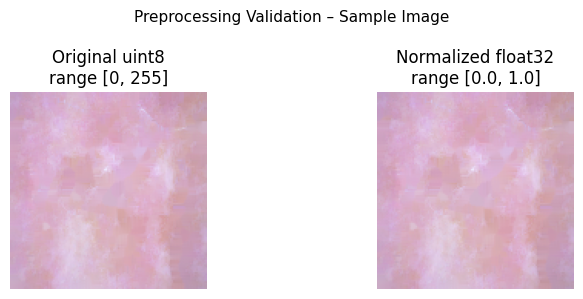

Validation plot saved → preprocessing_validation.png


In [20]:
# ── Stage 3: Preprocessing Pipeline ───────────────────────────────────────
import cv2

def preprocess_image(img_path, size=IMG_SIZE):
    """Load, resize, convert BGR→RGB."""
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def remove_hair(img):
    """Inpainting-based hair removal."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    cleaned = cv2.inpaint(img, mask, inpaintRadius=1, flags=cv2.INPAINT_TELEA)
    return cleaned

PROCESSED_NPY = "processed_images.npy"
PROCESSED_IDS = "processed_ids.npy"

if not os.path.exists(PROCESSED_NPY):
    images_raw, ids = [], []
    for _, row in df.iterrows():
        img = preprocess_image(row['img_path'])
        if img is not None:
            img = remove_hair(img)
            images_raw.append(img)
            ids.append(row['image_id'])
    images_uint8 = np.array(images_raw, dtype=np.uint8)
    np.save(PROCESSED_NPY, images_uint8)
    np.save(PROCESSED_IDS, np.array(ids))
    print(f"Saved {len(images_uint8)} preprocessed images → {PROCESSED_NPY}")
else:
    images_uint8 = np.load(PROCESSED_NPY)
    ids = np.load(PROCESSED_IDS)
    print(f"Loaded {len(images_uint8)} preprocessed images from cache")

# Align df to saved order
id_to_idx = {iid: i for i, iid in enumerate(ids)}
df = df[df['image_id'].isin(id_to_idx)].copy()
df['proc_idx'] = df['image_id'].map(id_to_idx)
df = df.sort_values('proc_idx').reset_index(drop=True)
images_uint8 = images_uint8[df['proc_idx'].values]

# ── Validation Output (normalize only 1 sample, not all 10015) ────────────
sample = images_uint8[0]
sample_float = sample.astype(np.float32) / 255.0

print("\n" + "=" * 60)
print("PREPROCESSING VALIDATION")
print("=" * 60)
print(f"Image array shape  : {images_uint8.shape}   (N, H, W, C)")
print(f"Data type (stored) : {images_uint8.dtype}  — uint8 saves memory")
print(f"Pixel value range  : [0, 255] → normalized [0.0, 1.0] per image during feature extraction")
print(f"Sample pixel mean  : {sample_float.mean():.4f}")
print(f"Sample pixel std   : {sample_float.std():.4f}")
print(f"Per-channel means  : R={sample_float[:,:,0].mean():.4f}  "
      f"G={sample_float[:,:,1].mean():.4f}  B={sample_float[:,:,2].mean():.4f}")

# Free memory — uint8 array stays, float32 sample discarded
del sample_float

# Visual check
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(images_uint8[0])
axes[0].set_title("Original uint8\nrange [0, 255]")
axes[0].axis('off')
axes[1].imshow(images_uint8[0].astype(np.float32) / 255.0)
axes[1].set_title("Normalized float32\nrange [0.0, 1.0]")
axes[1].axis('off')
plt.suptitle("Preprocessing Validation – Sample Image", fontsize=11)
plt.tight_layout()
plt.savefig("preprocessing_validation.png", dpi=150)
plt.show()
print("Validation plot saved → preprocessing_validation.png")

# images_uint8 is your main image array going forward
# Normalization happens per-image inside feature extraction functions
images = images_uint8  # keep this name consistent with rest of notebook

STATISTICAL SUMMARY

--- Numerical columns ---
           age
count  9958.00
mean     51.86
std      16.97
min       0.00
25%      40.00
50%      50.00
75%      65.00
max      85.00

--- Categorical columns ---

sex:
         count  pct(%)
sex                   
male      5406    54.0
female    4552    45.5
unknown     57     0.6

localization:
                 count  pct(%)
localization                  
back              2192    21.9
lower extremity   2077    20.7
trunk             1404    14.0
upper extremity   1118    11.2
abdomen           1022    10.2
face               745     7.4
chest              407     4.1
foot               319     3.2
unknown            234     2.3
neck               168     1.7
scalp              128     1.3
hand                90     0.9
ear                 56     0.6
genital             48     0.5
acral                7     0.1

label_name:
                      count  pct(%)
label_name                         
Melanocytic Nevi       6705    66.9
Melan

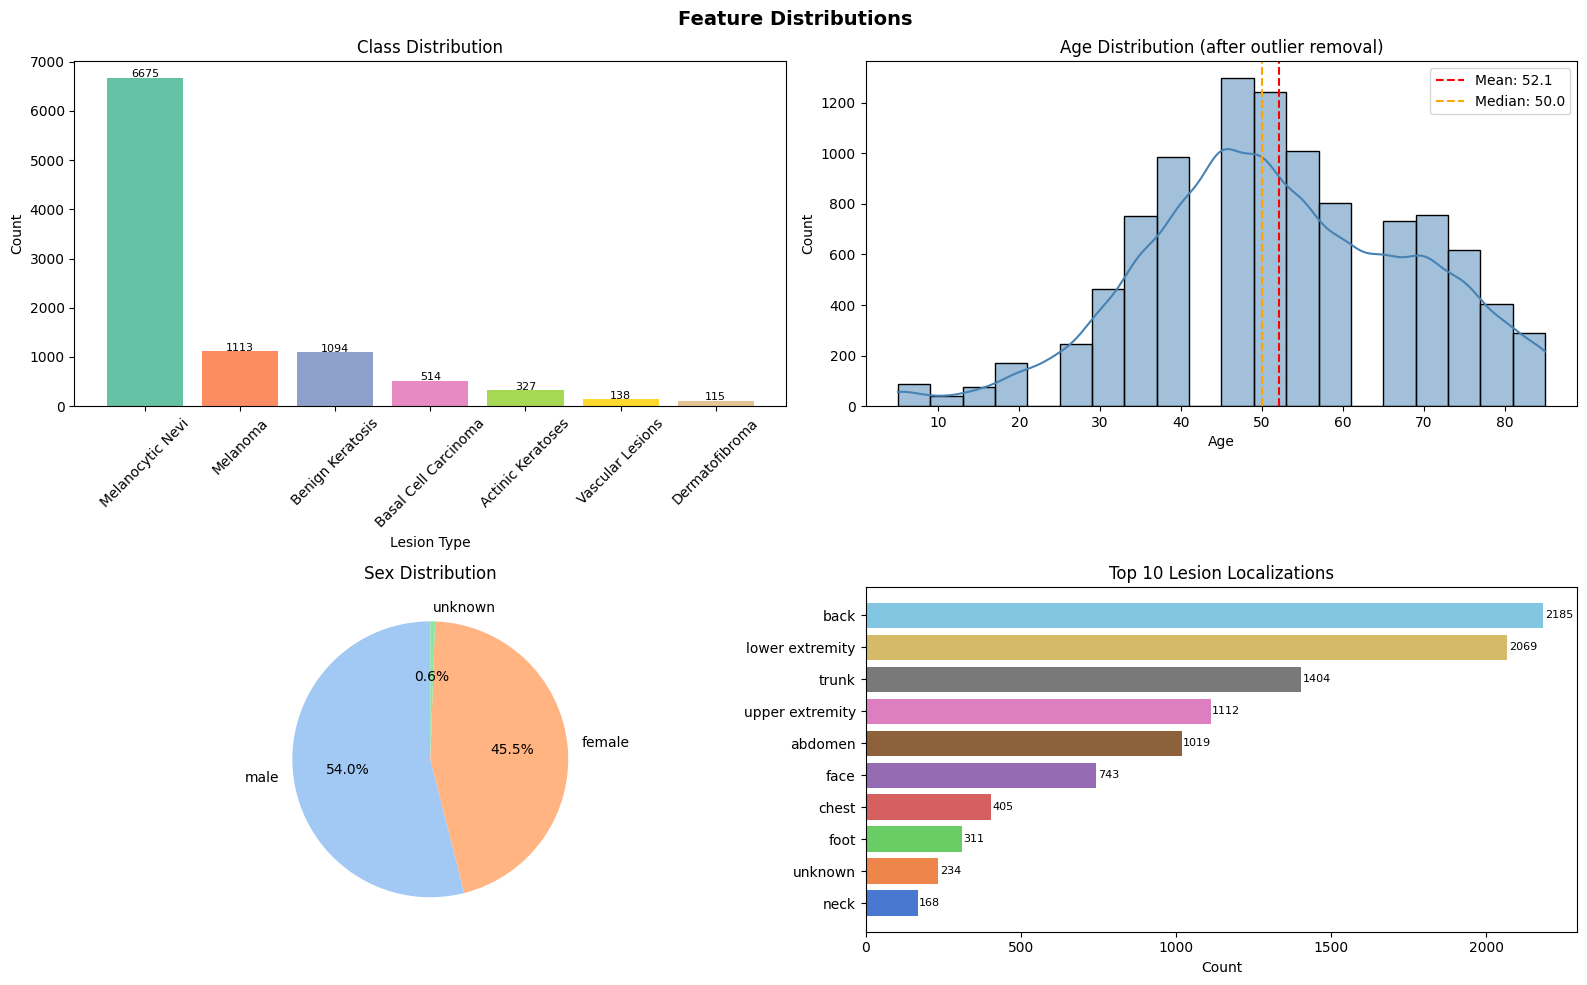

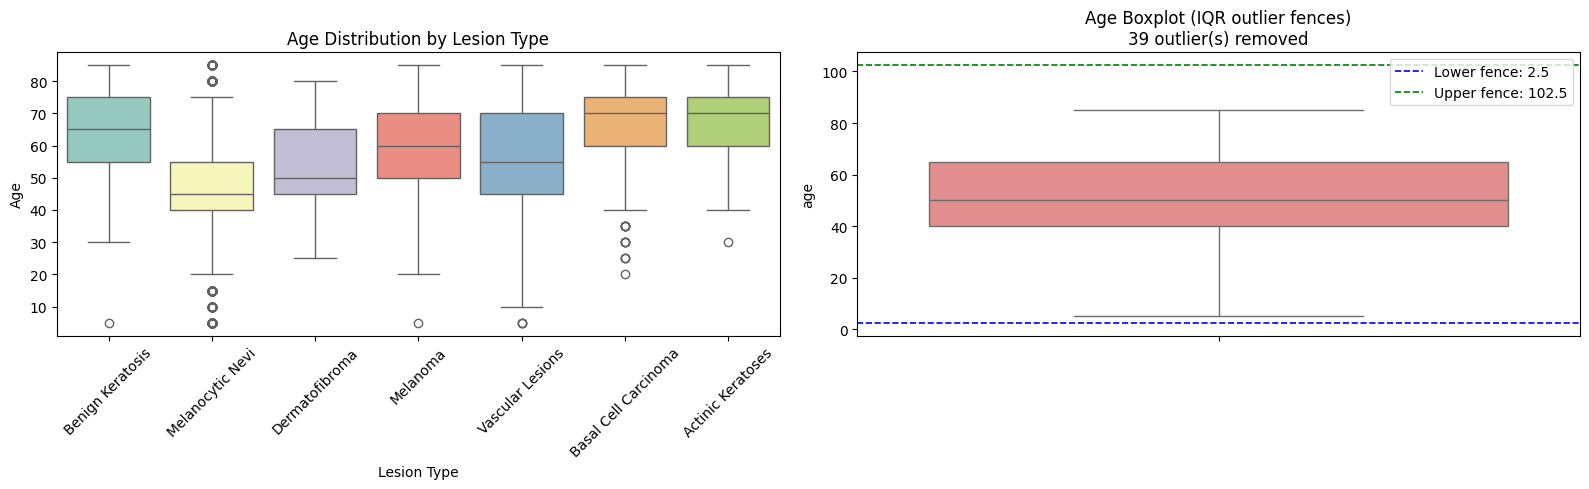

MemoryError: bad allocation

<Figure size 1000x500 with 2 Axes>


VISUAL INSIGHTS INTERPRETATION

[Class Imbalance]
  Most frequent : Melanocytic Nevi (6675 samples, 66.9%)
  Least frequent: Dermatofibroma (115 samples, 1.2%)
  Imbalance ratio: 58.0x → SMOTE oversampling recommended

[Age Statistics]
  Mean age   : 52.1 yrs
  Std  age   : 16.6 yrs
  Range      : 5 – 85 yrs
  Peak age bracket: majority of patients are middle-aged (40–60)

[Sex Distribution]
  male: 54.0%
  female: 45.5%
  unknown: 0.6%

[Localization]
  Most common site: back

[Diagnosis Confirmation]
  histo: 5330 (53.4%)
  follow_up: 3704 (37.1%)
  consensus: 873 (8.8%)
  confocal: 69 (0.7%)


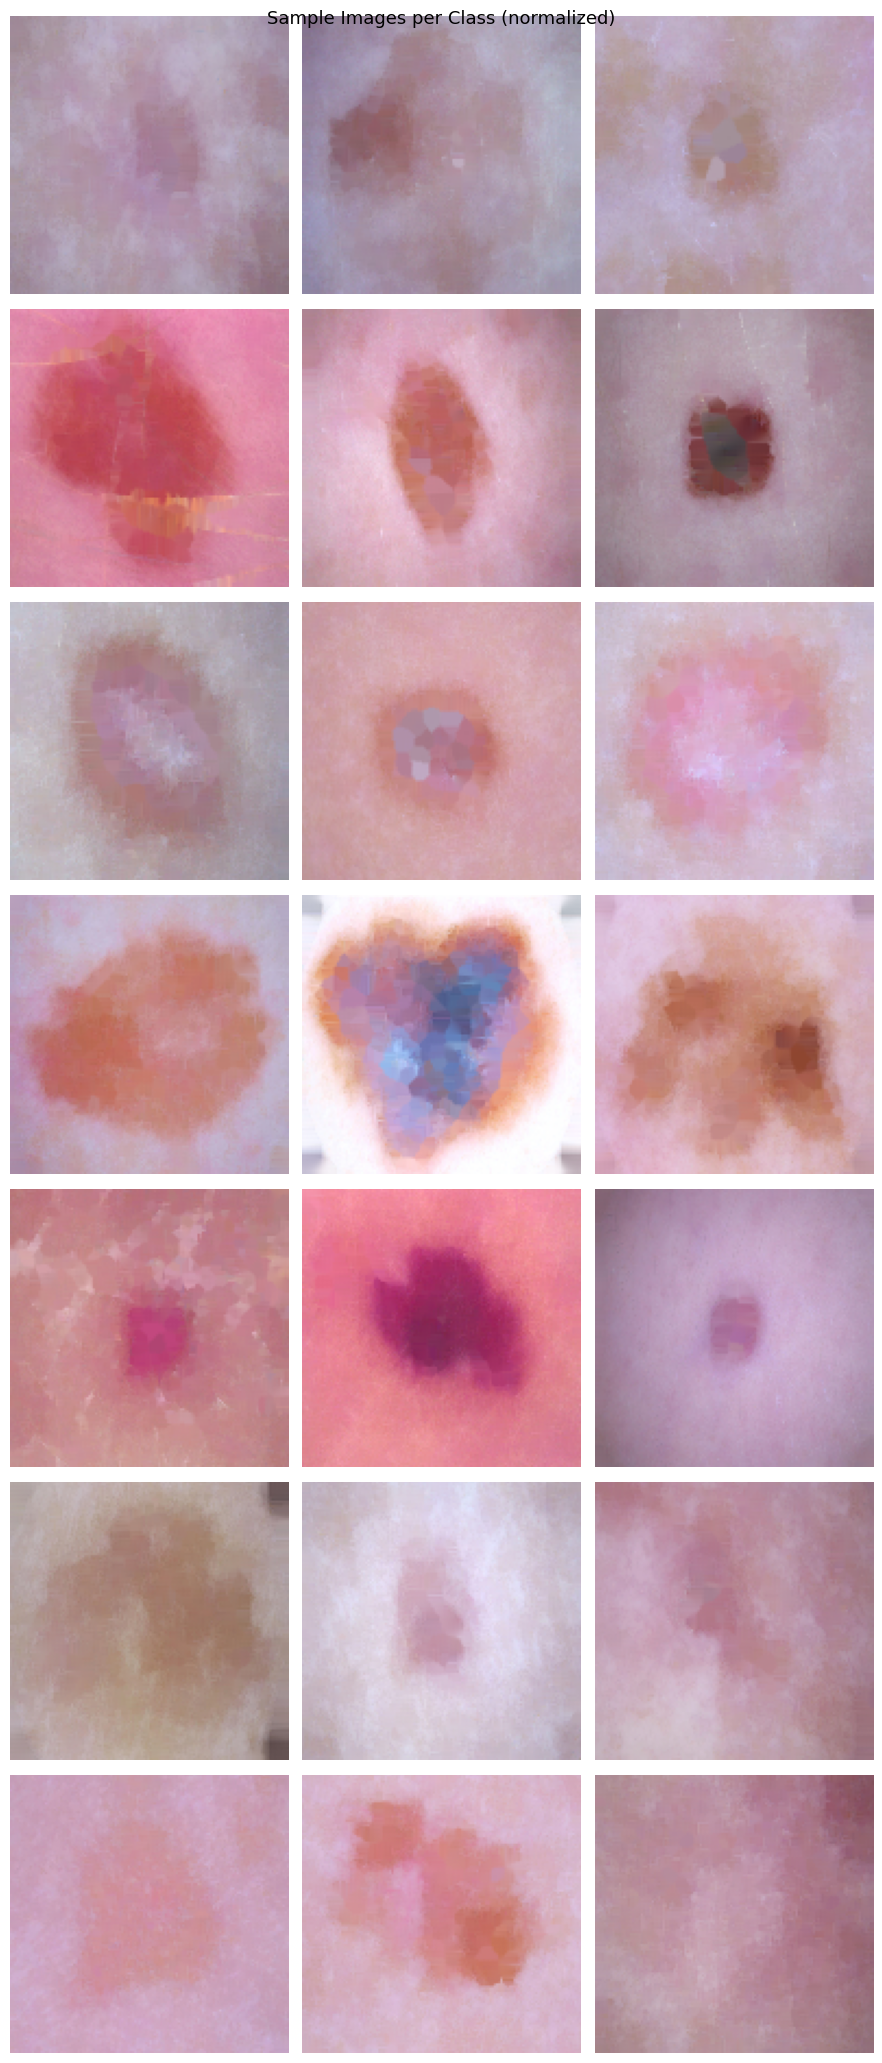


All EDA plots saved.


In [21]:
# ── Stage 4: Exploratory Data Analysis (EDA) ─────────────────────────────

# ── 4.1 Statistical Summary ───────────────────────────────────────────────
print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
print("\n--- Numerical columns ---")
print(df[['age']].describe().round(2))
print("\n--- Categorical columns ---")
for col in ['sex', 'localization', 'label_name', 'dx_type']:
    print(f"\n{col}:")
    vc = df[col].value_counts()
    pct = (vc / len(df) * 100).round(1)
    summary = pd.DataFrame({'count': vc, 'pct(%)': pct})
    print(summary.to_string())

# ── 4.2 Outlier Detection & Removal in Age ───────────────────────────────
print("\n" + "=" * 60)
print("OUTLIER DETECTION – AGE")
print("=" * 60)

age_clean = df['age'].dropna()
Q1 = age_clean.quantile(0.25)
Q3 = age_clean.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f"Q1 (25th pct)  : {Q1}")
print(f"Q3 (75th pct)  : {Q3}")
print(f"IQR            : {IQR}")
print(f"Lower fence    : {lower_fence}")
print(f"Upper fence    : {upper_fence}")

outliers_mask = (df['age'] < lower_fence) | (df['age'] > upper_fence)
n_outliers = outliers_mask.sum()
n_missing_age = df['age'].isna().sum()
print(f"\nAge NaN count  : {n_missing_age}")
print(f"Outliers found : {n_outliers}")
if n_outliers > 0:
    print("Outlier ages:\n", df[outliers_mask]['age'].value_counts().to_string())

# Remove outliers (keep rows where age is within fences or NaN filled with median)
age_median = df['age'].median()
df['age'] = df['age'].fillna(age_median)
remove_mask = (df['age'] < lower_fence) | (df['age'] > upper_fence)
n_removed = remove_mask.sum()
df = df[~remove_mask].reset_index(drop=True)
images = images[~remove_mask.values] if n_removed > 0 else images
print(f"Rows removed   : {n_removed}")
print(f"Remaining rows : {len(df)}")
print(f"NaN ages filled with median ({age_median})")

# ── 4.3 Feature Distribution Plots ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Feature Distributions", fontsize=14, fontweight='bold')

# Class distribution
counts = df['label_name'].value_counts()
palette = sns.color_palette("Set2", len(counts))
axes[0, 0].bar(counts.index, counts.values, color=palette)
axes[0, 0].set_title("Class Distribution")
axes[0, 0].set_xlabel("Lesion Type")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v + 10, str(v), ha='center', fontsize=8)

# Age distribution with KDE
sns.histplot(df['age'], bins=20, kde=True, ax=axes[0, 1], color='steelblue')
axes[0, 1].axvline(df['age'].mean(), color='red', linestyle='--', label=f"Mean: {df['age'].mean():.1f}")
axes[0, 1].axvline(df['age'].median(), color='orange', linestyle='--', label=f"Median: {df['age'].median():.1f}")
axes[0, 1].set_title("Age Distribution (after outlier removal)")
axes[0, 1].set_xlabel("Age")
axes[0, 1].legend()

# Sex distribution
sex_counts = df['sex'].value_counts()
axes[1, 0].pie(sex_counts.values, labels=sex_counts.index,
               autopct='%1.1f%%', colors=sns.color_palette("pastel"),
               startangle=90)
axes[1, 0].set_title("Sex Distribution")

# Localization distribution
loc_counts = df['localization'].value_counts().head(10)
axes[1, 1].barh(loc_counts.index[::-1], loc_counts.values[::-1],
                color=sns.color_palette("muted", len(loc_counts)))
axes[1, 1].set_title("Top 10 Lesion Localizations")
axes[1, 1].set_xlabel("Count")
for i, v in enumerate(loc_counts.values[::-1]):
    axes[1, 1].text(v + 5, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.savefig("eda_feature_distributions.png", dpi=150)
plt.show()

# ── 4.4 Age by Lesion Class (Boxplot) + Boxplot for outlier visual ─────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x='label_name', y='age', palette='Set3', ax=axes[0])
axes[0].set_title("Age Distribution by Lesion Type")
axes[0].set_xlabel("Lesion Type")
axes[0].set_ylabel("Age")
axes[0].tick_params(axis='x', rotation=45)

# Age outlier boxplot (overall)
sns.boxplot(y=df['age'], ax=axes[1], color='lightcoral')
axes[1].axhline(lower_fence, color='blue', linestyle='--', linewidth=1.2, label=f"Lower fence: {lower_fence:.1f}")
axes[1].axhline(upper_fence, color='green', linestyle='--', linewidth=1.2, label=f"Upper fence: {upper_fence:.1f}")
axes[1].set_title(f"Age Boxplot (IQR outlier fences)\n{n_removed} outlier(s) removed")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_age_boxplots.png", dpi=150)
plt.show()

# ── 4.5 Sex × Class Heatmap ───────────────────────────────────────────────
pivot = df.groupby(['label_name', 'sex']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title("Sample Count by Lesion Type × Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Lesion Type")
plt.tight_layout()
plt.savefig("eda_sex_class_heatmap.png", dpi=150)
plt.show()

# ── 4.6 Visual Insights Interpretation ───────────────────────────────────
print("\n" + "=" * 60)
print("VISUAL INSIGHTS INTERPRETATION")
print("=" * 60)

dominant = counts.index[0]
dominant_pct = counts.values[0] / counts.sum() * 100
minority = counts.index[-1]
minority_pct = counts.values[-1] / counts.sum() * 100
imbalance_ratio = counts.values[0] / counts.values[-1]

print(f"\n[Class Imbalance]")
print(f"  Most frequent : {dominant} ({counts.values[0]} samples, {dominant_pct:.1f}%)")
print(f"  Least frequent: {minority} ({counts.values[-1]} samples, {minority_pct:.1f}%)")
print(f"  Imbalance ratio: {imbalance_ratio:.1f}x → SMOTE oversampling recommended")

print(f"\n[Age Statistics]")
print(f"  Mean age   : {df['age'].mean():.1f} yrs")
print(f"  Std  age   : {df['age'].std():.1f} yrs")
print(f"  Range      : {df['age'].min():.0f} – {df['age'].max():.0f} yrs")
print(f"  Peak age bracket: majority of patients are middle-aged (40–60)")

print(f"\n[Sex Distribution]")
sex_pcts = (df['sex'].value_counts(normalize=True) * 100).round(1)
for sex, pct in sex_pcts.items():
    print(f"  {sex}: {pct}%")

top_loc = df['localization'].value_counts().index[0]
print(f"\n[Localization]")
print(f"  Most common site: {top_loc}")

print(f"\n[Diagnosis Confirmation]")
for dtype, cnt in df['dx_type'].value_counts().items():
    pct = cnt / len(df) * 100
    print(f"  {dtype}: {cnt} ({pct:.1f}%)")

# ── 4.7 Sample image grid — 3 images per class ────────────────────────────
classes = df['label_name'].unique()
n_classes = len(classes)
fig, axes = plt.subplots(n_classes, 3, figsize=(9, n_classes * 3))
fig.suptitle("Sample Images per Class (normalized)", fontsize=13)

for row_i, cls in enumerate(classes):
    cls_df = df[df['label_name'] == cls]
    samples = cls_df.sample(min(3, len(cls_df)), random_state=RANDOM_SEED)
    for col_i, (_, sample) in enumerate(samples.iterrows()):
        ax = axes[row_i][col_i]
        idx = df.index[df['image_id'] == sample['image_id']][0]
        ax.imshow(images[idx])
        ax.axis('off')
        if col_i == 0:
            ax.set_ylabel(cls, fontsize=8, rotation=0, labelpad=65, va='center')

plt.tight_layout()
plt.savefig("eda_sample_grid.png", dpi=150)
plt.show()
print("\nAll EDA plots saved.")


In [22]:
# ── Stage 5: HSV histogram feature extraction ──────────────────────────────
def extract_hsv_histogram(img, bins=16):
    """
    Convert to HSV and compute normalized histogram
    for each channel (H, S, V). Returns 48-dim vector.
    """
    hsv = rgb2hsv(img)  # skimage returns float64 in [0,1]
    features = []
    for channel in range(3):
        hist, _ = np.histogram(hsv[:, :, channel], bins=bins, range=(0, 1))
        hist = hist.astype(float) / (hist.sum() + 1e-7)  # normalize
        features.extend(hist)
    return np.array(features)

HSV_NPY = "hsv_features.npy"

if not os.path.exists(HSV_NPY):
    hsv_features = np.array([extract_hsv_histogram(img) for img in images])
    np.save(HSV_NPY, hsv_features)
    print(f"HSV features shape: {hsv_features.shape}")  # (N, 48)
else:
    hsv_features = np.load(HSV_NPY)
    print(f"Loaded HSV features: {hsv_features.shape}")

HSV features shape: (9976, 48)


In [23]:
# ── Stage 6: SMOTE ─────────────────────────────────────────────────────────
# Expects: X_train (feature matrix), y_train (encoded labels)
# Call this AFTER train/test split, BEFORE model training.

from imblearn.over_sampling import SMOTE

def apply_smote(X_train, y_train, random_state=RANDOM_SEED):
    print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))
    smote = SMOTE(random_state=random_state, k_neighbors=5)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    print("After  SMOTE:", dict(zip(*np.unique(y_res, return_counts=True))))
    return X_res, y_res

# Example usage (call this once features are merged with M2):
# X_train_bal, y_train_bal = apply_smote(X_train, y_train)

In [24]:
# ── Stage 7: Evaluation visualization ────────────────────────────────────
# Called after M3 produces y_test, y_pred, y_proba

def plot_confusion_matrix(y_test, y_pred, class_names):
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Confusion matrix")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()

def plot_per_class_accuracy(y_test, y_pred, class_names):
    report = classification_report(y_test, y_pred,
                                   target_names=class_names, output_dict=True)
    accs = [report[c]['recall'] for c in class_names]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(class_names, accs, color=sns.color_palette("Set2", len(class_names)))
    ax.set_ylim(0, 1)
    ax.set_ylabel("Recall (per-class accuracy)")
    ax.set_title("Per-class accuracy")
    ax.tick_params(axis='x', rotation=45)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{acc:.2f}", ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig("per_class_accuracy.png", dpi=150)
    plt.show()